Saving text_label_dataset.csv to text_label_dataset.csv
Dataset shape: (1000, 3)


,id,text,label
0,1,I would not recommend this phone. Overpriced q...,negative
1,2,"Loved the app, fantastic experience from start...",positive
2,3,"It is an ordinary restaurant, neither good nor...",neutral
3,4,Worst game I have used this year. Simply unrel...,negative
4,5,I would not recommend this camera. Useless qua...,negative


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1000 non-null   int64 
 1   text    1000 non-null   object
 2   label   1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB
None

Missing values:
id       0
text     0
label    0
dtype: int64

Class distribution:
label
positive    334
negative    333
neutral     333
Name: count, dtype: int64


,text,clean_text,label
0,I would not recommend this phone. Overpriced q...,i would not recommend this phone overpriced qu...,negative
1,"Loved the app, fantastic experience from start...",loved the app fantastic experience from start ...,positive
2,"It is an ordinary restaurant, neither good nor...",it is an ordinary restaurant neither good nor ...,neutral
3,Worst game I have used this year. Simply unrel...,worst game i have used this year simply unreli...,negative
4,I would not recommend this camera. Useless qua...,i would not recommend this camera useless qual...,negative


Training samples: 800
Testing samples: 200
Model training completed!
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        67
     neutral       1.00      1.00      1.00        66
    positive       1.00      1.00      1.00        67

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



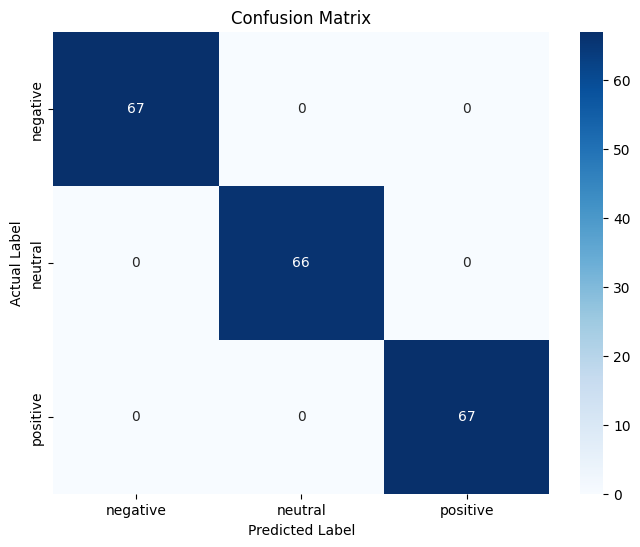

Input: This is an amazing product and I really enjoyed it.
Prediction: positive
Confidence: 53.66%
Text: I absolutely loved this product!
Prediction: positive
Confidence: 85.38%
------------------------------------------------------------
Text: The service was terrible.
Prediction: positive
Confidence: 45.44%
------------------------------------------------------------
Text: The movie was okay.
Prediction: neutral
Confidence: 55.02%
------------------------------------------------------------
Text: I would definitely recommend this.
Prediction: positive
Confidence: 72.44%
------------------------------------------------------------
Pipeline saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Prediction: positive


In [1]:
#Install dependencies
!pip -q install pandas scikit-learn nltk matplotlib seaborn joblib
#2. Import libraries
import re
import string
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
#3. Load dataset
#Your CSV should contain two columns:
#•	text — input sentence/document
#•	label — target class
# Upload your CSV in Colab
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv("text_label_dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())
#If your columns have different names:
# Example:
# df = df.rename(columns={
#     "message": "text",
#     "category": "label"
# })
#4. Check and clean the data
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Remove missing rows
df = df.dropna(subset=["text", "label"])

# Convert to string
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

print("\nClass distribution:")
print(df["label"].value_counts())
#5. Text preprocessing
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

display(df[["text", "clean_text", "label"]].head())
#6. Split the dataset
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
#7. Build the NLP pipeline
#The pipeline automatically performs:
#Text → TF-IDF → Logistic Regression → Prediction
nlp_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])
#8. Train the model
nlp_pipeline.fit(X_train, y_train)

print("Model training completed!")
#9. Evaluate the model
y_pred = nlp_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
#10. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()
#11. Test with new text
def predict_text(text):
    cleaned = clean_text(text)

    prediction = nlp_pipeline.predict([cleaned])[0]

    # Probability, if available
    probabilities = nlp_pipeline.predict_proba([cleaned])[0]
    classes = nlp_pipeline.classes_

    confidence = max(probabilities)

    return prediction, confidence


text = "This is an amazing product and I really enjoyed it."

prediction, confidence = predict_text(text)

print("Input:", text)
print("Prediction:", prediction)
print(f"Confidence: {confidence:.2%}")
#12. Test multiple sentences
texts = [
    "I absolutely loved this product!",
    "The service was terrible.",
    "The movie was okay.",
    "I would definitely recommend this."
]

for text in texts:
    prediction, confidence = predict_text(text)

    print(f"Text: {text}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2%}")
    print("-" * 60)
#13. Save the complete NLP model
#Because the preprocessing and classifier are inside the pipeline, you only need to save one file.
joblib.dump(nlp_pipeline, "nlp_pipeline.pkl")

print("Pipeline saved successfully.")
#14. Download the model
from google.colab import files

files.download("nlp_pipeline.pkl")
#15. Load the model later
loaded_pipeline = joblib.load("nlp_pipeline.pkl")

text = "I really enjoyed this experience."

prediction = loaded_pipeline.predict([clean_text(text)])

print("Prediction:", prediction[0])